In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objs as go

In [2]:
from pandas_datareader import data,wb

In [3]:
from datetime import datetime as dt
import yfinance as yf 
import pytz

In [4]:
tz = pytz.timezone("Asia/Kolkata")
start = tz.localize(dt(2015,1,1))
end = tz.localize(dt.today())

In [5]:

df = yf.download('MSFT',start,end)
df.head()

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-12-31,46.730000,47.439999,46.450001,46.450001,40.110382,21552500
2015-01-02,46.660000,47.419998,46.540001,46.759998,40.378075,27913900
2015-01-05,46.369999,46.730000,46.250000,46.330002,40.006760,39673900
2015-01-06,46.380001,46.750000,45.540001,45.650002,39.419563,36447900
2015-01-07,45.980000,46.459999,45.490002,46.230000,39.920410,29114100


In [6]:
df = df.reset_index()
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-12-31,46.730000,47.439999,46.450001,46.450001,40.110382,21552500
1,2015-01-02,46.660000,47.419998,46.540001,46.759998,40.378075,27913900
2,2015-01-05,46.369999,46.730000,46.250000,46.330002,40.006760,39673900
3,2015-01-06,46.380001,46.750000,45.540001,45.650002,39.419563,36447900
4,2015-01-07,45.980000,46.459999,45.490002,46.230000,39.920410,29114100


In [7]:
df = df.drop(['Date'], axis = 1)
df.head()

,Open,High,Low,Close,Adj Close,Volume
0,46.730000,47.439999,46.450001,46.450001,40.110382,21552500
1,46.660000,47.419998,46.540001,46.759998,40.378075,27913900
2,46.369999,46.730000,46.250000,46.330002,40.006760,39673900
3,46.380001,46.750000,45.540001,45.650002,39.419563,36447900
4,45.980000,46.459999,45.490002,46.230000,39.920410,29114100


In [8]:
from matplotlib import pyplot as plt

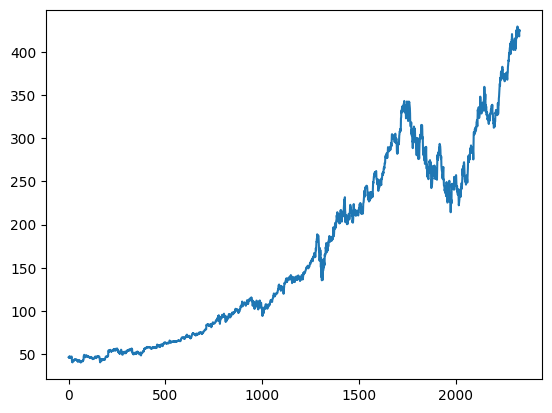

In [9]:
plt.plot(df.Close)

In [10]:
ma100 = df.Close.rolling(100).mean()
ma100

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
2327    393.232801
2328    393.832001
2329    394.378801
2330    395.027101
2331    395.576300
Name: Close, Length: 2332, dtype: float64

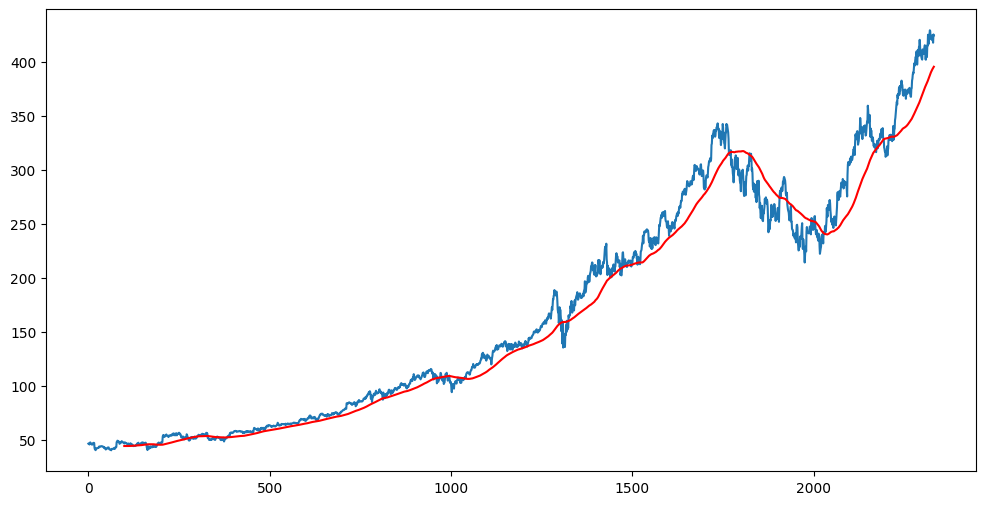

In [11]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100,'r')

In [12]:
df.shape


(2332, 6)

In [13]:
data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70): int(len(df))])

print(data_training.shape)
print(data_testing.shape)

(1632, 1)
(700, 1)


In [14]:
data_training.head()

,Close
0,46.450001
1,46.759998
2,46.330002
3,45.650002
4,46.230000


In [15]:
data_testing.head()

,Close
1632,265.019989
1633,268.720001
1634,271.399994
1635,270.899994
1636,271.600006


In [16]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [17]:
data_training_arr = scaler.fit_transform(data_training)
data_training_arr

array([[0.02720848],
       [0.02857773],
       [0.02667845],
       ...,
       [0.99478802],
       [0.99372786],
       [1.        ]])

In [18]:
data_training_arr.shape

(1632, 1)

In [19]:
x_train = []
y_train = []

for i in range(100,data_training_arr.shape[0]):
    x_train.append(data_training_arr[i-100: i])
    y_train.append(data_training_arr[i,0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [20]:
x_train.shape

(1532, 100, 1)

In [21]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [22]:
model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences = True, 
               input_shape = (x_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, activation = 'relu', return_sequences = True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units = 1))

C:\Users\Hrishikesh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 50)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 100, 60)             │          26,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100, 60)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 100, 80)             │          45,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 100, 80)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 120)                 │          96,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 120)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             121 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(optimizer = 'adam', loss = 'mean_absolute_error')
model.fit(x_train, y_train, epochs = 50)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 14s 166ms/step - loss: 0.2018
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 190ms/step - loss: 0.0533
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 186ms/step - loss: 0.0513
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 194ms/step - loss: 0.0528
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 186ms/step - loss: 0.0472
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 185ms/step - loss: 0.0497
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 181ms/step - loss: 0.0441
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 184ms/step - loss: 0.0433
Epoch 9/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 211ms/step - loss: 0.0459
Epoch 10/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 192ms/step - loss: 0.0399
Epoch 11/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step - loss: 0.0445
Epoch 12/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 194ms/step - loss: 0.0423
Epoch 13/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 188ms/step - loss: 0.0422
Epoch 14/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 183ms/step - loss: 0.0429
Epoch 15/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 185ms/step - 

In [25]:
model.save('keras_model.keras')

In [26]:
data_testing.head()

,Close
1632,265.019989
1633,268.720001
1634,271.399994
1635,270.899994
1636,271.600006


In [27]:
data_training.tail()

,Close
1627,259.429993
1628,262.630005
1629,265.510010
1630,265.269989
1631,266.690002


In [28]:
data_training.head()

,Close
0,46.450001
1,46.759998
2,46.330002
3,45.650002
4,46.230000


In [29]:
past_100_days = data_training.tail(100)

In [30]:
final_df = pd.concat([data_testing,past_100_days], ignore_index=True)

In [31]:
final_df.head()

,Close
0,265.019989
1,268.720001
2,271.399994
3,270.899994
4,271.600006


In [32]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.23600776],
       [0.25320752],
       [0.26566565],
       [0.26334137],
       [0.26659542],
       [0.2947192 ],
       [0.29476574],
       [0.30531793],
       [0.29365012],
       [0.29606733],
       [0.29318524],
       [0.31019902],
       [0.31731132],
       [0.31043139],
       [0.3091298 ],
       [0.29174419],
       [0.30248238],
       [0.31215134],
       [0.33418565],
       [0.35059509],
       [0.34771286],
       [0.33604505],
       [0.33455747],
       [0.33585906],
       [0.32846786],
       [0.3280495 ],
       [0.33874115],
       [0.33590559],
       [0.34989769],
       [0.34961879],
       [0.34436588],
       [0.33558016],
       [0.33795098],
       [0.35124581],
       [0.3653775 ],
       [0.3735125 ],
       [0.36644658],
       [0.35552256],
       [0.38359981],
       [0.41888243],
       [0.42023055],
       [0.41079396],
       [0.4079584 ],
       [0.39438452],
       [0.39731314],
       [0.41530308],
       [0.40735407],
       [0.407

In [33]:
input_data.shape

(800, 1)

In [34]:
x_test = []
y_test = []

for i in range(100,input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i,0])

In [35]:
x_test, y_test = np.array(x_test), np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(700, 100, 1)
(700,)


In [36]:
#Predictions

y_predicted = model.predict(x_test)


22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step


In [37]:
y_predicted.shape

(700, 1)

In [38]:
y_test

array([0.58227972, 0.58046671, 0.5904611 , 0.59901445, 0.58376715,
       0.57377276, 0.57484198, 0.53658421, 0.56889182, 0.54081442,
       0.53844361, 0.53570097, 0.50557834, 0.52036075, 0.5609428 ,
       0.56117518, 0.55248238, 0.59636487, 0.5817683 , 0.53035515,
       0.5596876 , 0.51436406, 0.50925061, 0.49116775, 0.52547421,
       0.55294726, 0.55987358, 0.59594652, 0.59036818, 0.59362223,
       0.58139648, 0.56745077, 0.56015249, 0.53346975, 0.47475831,
       0.46313689, 0.46388068, 0.46494975, 0.46825034, 0.48354403,
       0.42092781, 0.44603019, 0.41093341, 0.41409441, 0.40605247,
       0.38015991, 0.38174041, 0.34510967, 0.38332091, 0.39787095,
       0.43701196, 0.44965607, 0.43933624, 0.46118443, 0.40442545,
       0.42622724, 0.40303093, 0.4198122 , 0.45072515, 0.40967835,
       0.37555788, 0.37537189, 0.40079957, 0.39629045, 0.35552256,
       0.34250648, 0.34153032, 0.30689843, 0.37346596, 0.38611008,
       0.39299001, 0.37513952, 0.39949798, 0.37964864, 0.35147

In [39]:
y_predicted

array([[0.54715437],
       [0.5550518 ],
       [0.56233525],
       [0.5691395 ],
       [0.57560503],
       [0.5817346 ],
       [0.5874295 ],
       [0.59260476],
       [0.59698707],
       [0.6005744 ],
       [0.6033001 ],
       [0.60513914],
       [0.6061223 ],
       [0.60616773],
       [0.6053415 ],
       [0.6040106 ],
       [0.6025423 ],
       [0.6011588 ],
       [0.6002126 ],
       [0.5998808 ],
       [0.59991235],
       [0.600176  ],
       [0.60033166],
       [0.6000762 ],
       [0.5991402 ],
       [0.59759057],
       [0.5957524 ],
       [0.59397966],
       [0.59272   ],
       [0.59225494],
       [0.5927074 ],
       [0.59399426],
       [0.595863  ],
       [0.5980058 ],
       [0.6000135 ],
       [0.6012498 ],
       [0.6012188 ],
       [0.5997083 ],
       [0.5967523 ],
       [0.5925592 ],
       [0.58749825],
       [0.58160233],
       [0.57503474],
       [0.5678294 ],
       [0.56006336],
       [0.5518286 ],
       [0.5431318 ],
       [0.534

In [40]:
scaler.scale_

array([0.00464857])

In [41]:
scaling_factor = 1/0.04412167
y_predicted = y_predicted * scaling_factor
y_test = y_test * scaling_factor

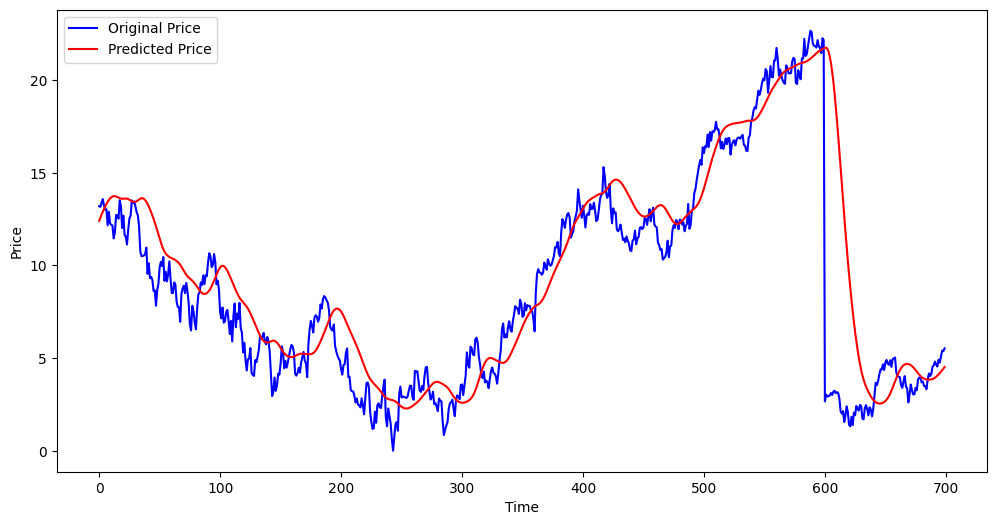

In [42]:
plt.figure(figsize=(12,6))
plt.plot(y_test, 'b', label = 'Original Price')
plt.plot(y_predicted, 'r', label = 'Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()